In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("titanic_fostwom.csv")

df.head()

,PClass,Age,Sex,Survived
0,1.0,29.0,1.0,1
1,1.0,2.0,0.0,0
2,1.0,NaN,0.0,0
3,NaN,25.0,1.0,0
4,1.0,1.0,0.0,1


In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(756, 4)
<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   PClass    739 non-null    float64
 1   Age       750 non-null    float64
 2   Sex       751 non-null    float64
 3   Survived  756 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 23.8 KB
None
PClass      17
Age          6
Sex          5
Survived     0
dtype: int64


In [5]:
print(df.head())
print(df.shape)
print(df.columns)

   PClass   Age  Sex  Survived
0     1.0  29.0  1.0         1
1     1.0   2.0  0.0         0
2     1.0   NaN  0.0         0
3     NaN  25.0  1.0         0
4     1.0   1.0  0.0         1
(756, 4)
Index(['PClass', 'Age', 'Sex', 'Survived'], dtype='str')


In [7]:
print(df.columns.tolist())

['PClass', 'Age', 'Sex', 'Survived']


In [8]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [11]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

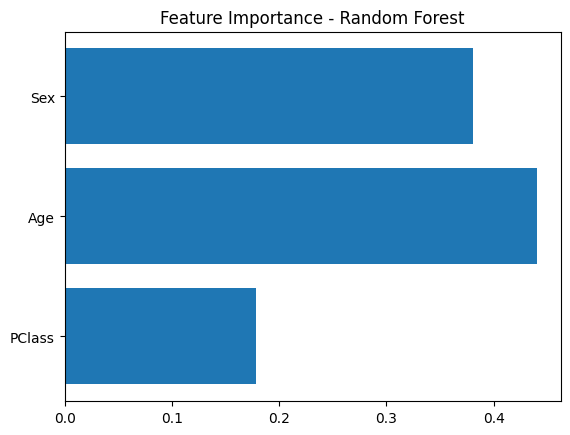

In [12]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance - Random Forest")
plt.show()

In [13]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Decision Tree Accuracy: 0.7894736842105263
Random Forest Accuracy: 0.7828947368421053
